In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

PROCESSED_DATA_PATH = "data/processed/weekly_beer_data.csv"
TEST_WEEKS = 26
LAGS = [1, 2, 3, 4, 8, 12, 26, 52]
WEEK_FREQ = "W-MON"
EXCLUDE_CONTAINER_KEYWORDS = ("can",)
RANDOM_STATE = 42


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6)) * 100)


def seasonal_terms(week_of_year: int) -> tuple[float, float]:
    angle = 2 * np.pi * (week_of_year / 52.18)
    return float(np.sin(angle)), float(np.cos(angle))


def prepare_series(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values("week").drop_duplicates(subset=["week"], keep="last").copy()
    full_weeks = pd.date_range(g["week"].min(), g["week"].max(), freq=WEEK_FREQ)
    g = g.set_index("week").reindex(full_weeks)
    g.index.name = "week"
    g = g.reset_index()

    g["liters"] = pd.to_numeric(g["liters"], errors="coerce").fillna(0.0).clip(lower=0.0)

    if "temp_mean" in g.columns:
        g["temp_mean"] = pd.to_numeric(g["temp_mean"], errors="coerce").interpolate(limit_direction="both")
        g["temp_mean"] = g["temp_mean"].fillna(g["temp_mean"].mean())
    else:
        g["temp_mean"] = np.nan

    if "rain_mm" in g.columns:
        g["rain_mm"] = pd.to_numeric(g["rain_mm"], errors="coerce").interpolate(limit_direction="both")
        g["rain_mm"] = g["rain_mm"].fillna(g["rain_mm"].mean())
    else:
        g["rain_mm"] = np.nan

    if "event_week" not in g.columns:
        g["event_week"] = 0
    g["event_week"] = pd.to_numeric(g["event_week"], errors="coerce").fillna(0).astype(int)

    g["week_of_year"] = g["week"].dt.isocalendar().week.astype(int)
    g["month"] = g["week"].dt.month.astype(int)
    g["year"] = g["week"].dt.year.astype(int)

    temp_thresh = float(np.nanquantile(g["temp_mean"], 0.75)) if g["temp_mean"].notna().any() else np.nan
    rain_thresh = float(np.nanquantile(g["rain_mm"], 0.75)) if g["rain_mm"].notna().any() else np.nan

    g["hot_week"] = 0 if np.isnan(temp_thresh) else (g["temp_mean"] >= temp_thresh).astype(int)
    g["rainy_week"] = 0 if np.isnan(rain_thresh) else (g["rain_mm"] >= rain_thresh).astype(int)

    g["sin_woy"] = g["week_of_year"].apply(lambda w: seasonal_terms(int(w))[0]).astype(float)
    g["cos_woy"] = g["week_of_year"].apply(lambda w: seasonal_terms(int(w))[1]).astype(float)
    return g


def add_features(df: pd.DataFrame, lags: list[int]) -> tuple[pd.DataFrame, list[str]]:
    out = df.sort_values("week").copy()
    for lag in lags:
        out[f"lag_{lag}"] = out["liters"].shift(lag)

    out["roll_mean_4"] = out["liters"].shift(1).rolling(4, min_periods=1).mean()
    out["roll_mean_12"] = out["liters"].shift(1).rolling(12, min_periods=1).mean()
    out["roll_sum_4"] = out["liters"].shift(1).rolling(4, min_periods=1).sum()

    feature_cols = [f"lag_{lag}" for lag in lags] + [
        "roll_mean_4", "roll_mean_12", "roll_sum_4",
        "sin_woy", "cos_woy", "month", "year",
        "hot_week", "rainy_week", "event_week", "temp_mean", "rain_mm",
    ]
    return out, feature_cols


def make_feature_row(history: list[float], exog_row: pd.Series, lags: list[int]) -> dict:
    row = {
        "roll_mean_4": float(np.mean(history[-4:])) if history else 0.0,
        "roll_mean_12": float(np.mean(history[-12:])) if history else 0.0,
        "roll_sum_4": float(np.sum(history[-4:])) if history else 0.0,
        "sin_woy": float(exog_row["sin_woy"]),
        "cos_woy": float(exog_row["cos_woy"]),
        "month": int(exog_row["month"]),
        "year": int(exog_row["year"]),
        "hot_week": int(exog_row["hot_week"]),
        "rainy_week": int(exog_row["rainy_week"]),
        "event_week": int(exog_row["event_week"]),
        "temp_mean": float(exog_row["temp_mean"]) if pd.notna(exog_row["temp_mean"]) else 0.0,
        "rain_mm": float(exog_row["rain_mm"]) if pd.notna(exog_row["rain_mm"]) else 0.0,
    }
    for lag in lags:
        row[f"lag_{lag}"] = float(history[-lag]) if len(history) >= lag else 0.0
    return row


def recursive_predict(model_name, model, train_df, test_df, lags, feature_cols):
    history = train_df["liters"].astype(float).tolist()
    preds = []
    for _, exog_row in test_df.iterrows():
        if model_name == "Naive_Last_Week":
            pred = float(history[-1]) if history else 0.0
        elif model_name == "Naive_Seasonal_52":
            pred = float(history[-52]) if len(history) >= 52 else (float(history[-1]) if history else 0.0)
        else:
            row = make_feature_row(history, exog_row, lags)
            X_new = pd.DataFrame([row], columns=feature_cols).fillna(0.0)
            pred = float(model.predict(X_new)[0])
        pred = max(0.0, pred)
        preds.append(pred)
        history.append(pred)
    return np.array(preds, dtype=float)


def run_model(model_name, model_factory=None):
    df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=["week"])

    all_metrics = []
    all_preds = []

    for (beer, container), group in df.groupby(["beer", "container"], sort=True):
        if any(k in str(container).lower() for k in EXCLUDE_CONTAINER_KEYWORDS):
            continue
        if group["liters"].sum() <= 0:
            continue

        s = prepare_series(group)
        if len(s) <= TEST_WEEKS:
            continue

        train = s.iloc[:-TEST_WEEKS].copy()
        test = s.iloc[-TEST_WEEKS:].copy()

        lags = [lag for lag in LAGS if lag < len(train)]
        if not lags:
            continue

        feat_train, feature_cols = add_features(train, lags)
        feat_train = feat_train.dropna(subset=feature_cols).copy()
        if feat_train.empty:
            continue

        y_train = feat_train["liters"].clip(lower=0.0)
        model = None
        if model_factory is not None:
            model = model_factory(y_train)
            model.fit(feat_train[feature_cols], y_train)

        y_true = test["liters"].astype(float).values
        y_pred = recursive_predict(model_name, model, train, test, lags, feature_cols)

        all_metrics.append({
            "beer": beer,
            "container": container,
            "model": model_name,
            "MAE": float(mean_absolute_error(y_true, y_pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "SMAPE": smape(y_true, y_pred),
        })

        all_preds.append(pd.DataFrame({
            "week": test["week"].values,
            "beer": beer,
            "container": container,
            "model": model_name,
            "actual_liters": y_true,
            "pred_liters": y_pred,
        }))

    metrics_df = pd.DataFrame(all_metrics)
    preds_df = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame()

    if metrics_df.empty:
        print(f"No valid series for {model_name}")
        return metrics_df, preds_df

    print(f"Model: {model_name}")
    print(metrics_df[["MAE", "RMSE", "SMAPE"]].mean().to_frame("avg").T)

    per_beer = metrics_df.groupby("beer", as_index=False)[["MAE", "RMSE", "SMAPE"]].mean().sort_values("RMSE")
    display(per_beer)

    plt.figure(figsize=(10, 4))
    plt.bar(per_beer["beer"], per_beer["RMSE"], color="#1f77b4")
    plt.title(f"{model_name} - RMSE by beer (avg across containers)")
    plt.ylabel("RMSE (liters)")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return metrics_df, preds_df


def recursive_predict_arima(train_df, test_df, order=(2, 1, 2)):
    history = train_df["liters"].astype(float).tolist()
    preds = []
    for _ in range(len(test_df)):
        if len(history) < 8:
            pred = float(history[-1]) if history else 0.0
        else:
            try:
                fit = ARIMA(history, order=order).fit()
                pred = float(fit.forecast(steps=1)[0])
            except Exception:
                pred = float(history[-1]) if history else 0.0
        pred = max(0.0, pred)
        preds.append(pred)
        history.append(pred)
    return np.array(preds, dtype=float)


def recursive_predict_holt_winters(train_df, test_df, seasonal_periods=52):
    history = train_df["liters"].astype(float).tolist()
    preds = []
    for _ in range(len(test_df)):
        if len(history) < max(12, seasonal_periods // 2):
            pred = float(history[-1]) if history else 0.0
        else:
            try:
                fit = ExponentialSmoothing(
                    np.asarray(history, dtype=float),
                    trend="add",
                    seasonal="add" if len(history) >= seasonal_periods else None,
                    seasonal_periods=seasonal_periods if len(history) >= seasonal_periods else None,
                    initialization_method="estimated",
                ).fit(optimized=True)
                pred = float(fit.forecast(1)[0])
            except Exception:
                pred = float(history[-1]) if history else 0.0
        pred = max(0.0, pred)
        preds.append(pred)
        history.append(pred)
    return np.array(preds, dtype=float)


def run_time_series_model(model_name, ts_predict_fn):
    if not HAS_STATSMODELS:
        print("statsmodels is not available in this environment.")
        return pd.DataFrame(), pd.DataFrame()

    df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=["week"])

    all_metrics = []
    all_preds = []

    for (beer, container), group in df.groupby(["beer", "container"], sort=True):
        if any(k in str(container).lower() for k in EXCLUDE_CONTAINER_KEYWORDS):
            continue
        if group["liters"].sum() <= 0:
            continue

        s = prepare_series(group)
        if len(s) <= TEST_WEEKS:
            continue

        train = s.iloc[:-TEST_WEEKS].copy()
        test = s.iloc[-TEST_WEEKS:].copy()

        y_true = test["liters"].astype(float).values
        y_pred = ts_predict_fn(train, test)

        all_metrics.append({
            "beer": beer,
            "container": container,
            "model": model_name,
            "MAE": float(mean_absolute_error(y_true, y_pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "SMAPE": smape(y_true, y_pred),
        })

        all_preds.append(pd.DataFrame({
            "week": test["week"].values,
            "beer": beer,
            "container": container,
            "model": model_name,
            "actual_liters": y_true,
            "pred_liters": y_pred,
        }))

    metrics_df = pd.DataFrame(all_metrics)
    preds_df = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame()

    if metrics_df.empty:
        print(f"No valid series for {model_name}")
        return metrics_df, preds_df

    print(f"Model: {model_name}")
    print(metrics_df[["MAE", "RMSE", "SMAPE"]].mean().to_frame("avg").T)

    per_beer = metrics_df.groupby("beer", as_index=False)[["MAE", "RMSE", "SMAPE"]].mean().sort_values("RMSE")
    display(per_beer)

    plt.figure(figsize=(10, 4))
    plt.bar(per_beer["beer"], per_beer["RMSE"], color="#9467bd")
    plt.title(f"{model_name} - RMSE by beer (avg across containers)")
    plt.ylabel("RMSE (liters)")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return metrics_df, preds_df


MODEL_RESULTS = {}


Model: Naive_Last_Week
           MAE       RMSE      SMAPE
avg  61.129744  81.928515  85.902102


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,43.877949,48.947465,103.428062
0,Hoop Bleke Nelis,50.205000,75.893393,54.775039
2,Hoop Lager,87.724519,114.208206,111.666460


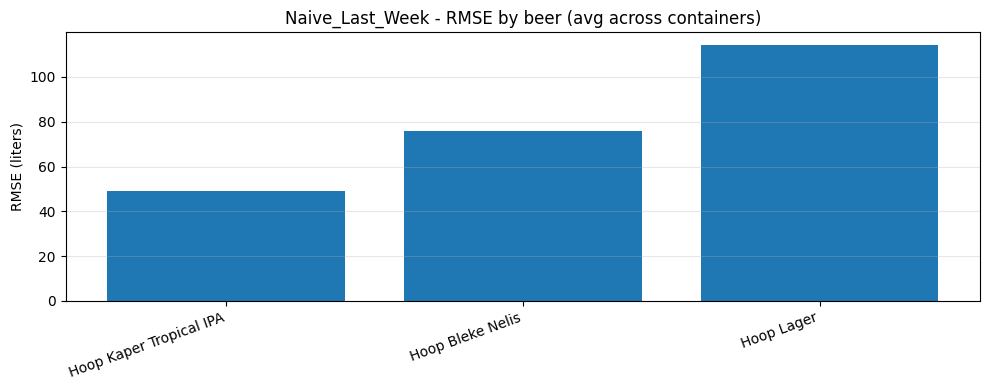

In [13]:
# 1) Naive last-week baseline
m, p = run_model("Naive_Last_Week", model_factory=None)
MODEL_RESULTS["Naive_Last_Week"] = {"metrics": m, "preds": p}

Model: Naive_Seasonal_52
           MAE        RMSE      SMAPE
avg  60.210545  111.442947  86.586838


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,42.694615,55.352048,137.963829
0,Hoop Bleke Nelis,59.120000,130.033211,69.749294
2,Hoop Lager,74.710673,130.273291,69.101025


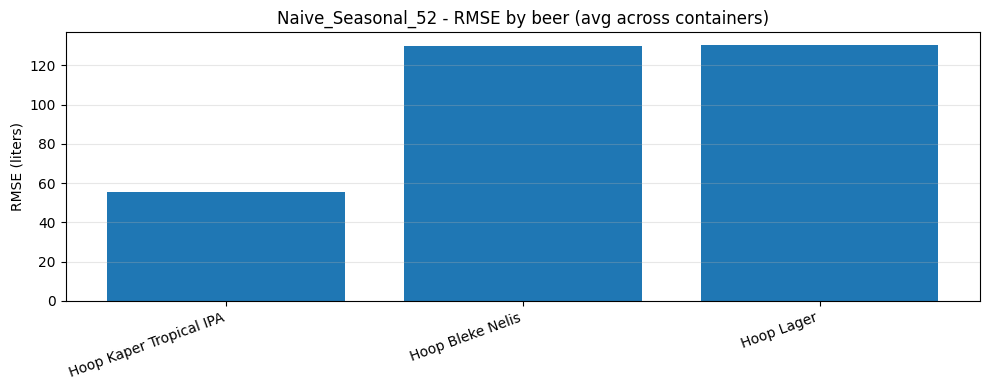

In [14]:
# 2) Seasonal naive baseline (52-week lag fallback)
m, p = run_model("Naive_Seasonal_52", model_factory=None)
MODEL_RESULTS["Naive_Seasonal_52"] = {"metrics": m, "preds": p}

Model: LinearRegression
           MAE       RMSE       SMAPE
avg  54.563708  77.700067  108.443659


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,32.213889,44.808796,92.871045
0,Hoop Bleke Nelis,43.107457,64.596734,101.786728
2,Hoop Lager,85.646385,118.747686,128.444283


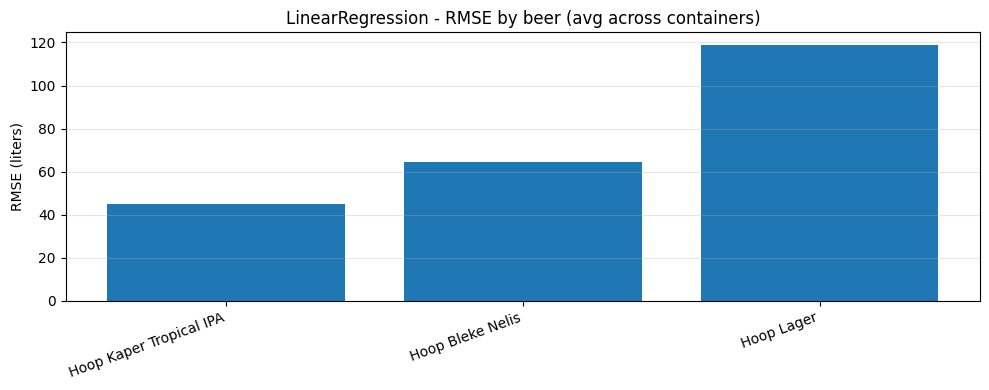

In [15]:
# 3) Linear Regression
m, p = run_model(
    "LinearRegression",
    model_factory=lambda y_train: LinearRegression(),
)
MODEL_RESULTS["LinearRegression"] = {"metrics": m, "preds": p}

Model: Ridge
           MAE       RMSE      SMAPE
avg  54.333342  77.351914  108.04792


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,31.891177,44.182120,91.963022
0,Hoop Bleke Nelis,42.938957,64.107583,101.393314
2,Hoop Lager,85.407948,118.784674,128.429851


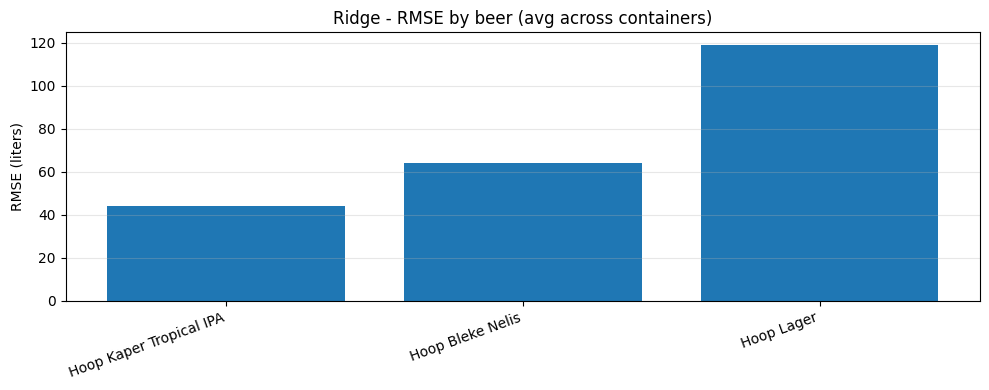

In [16]:
# 4) Ridge Regression
m, p = run_model(
    "Ridge",
    model_factory=lambda y_train: Ridge(alpha=1.0, random_state=RANDOM_STATE),
)
MODEL_RESULTS["Ridge"] = {"metrics": m, "preds": p}

Model: RandomForest
          MAE      RMSE       SMAPE
avg  59.18409  86.41411  111.272154


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,29.939832,40.478569,92.326352
0,Hoop Bleke Nelis,52.122317,79.915128,81.361961
2,Hoop Lager,89.944499,128.989492,162.869248


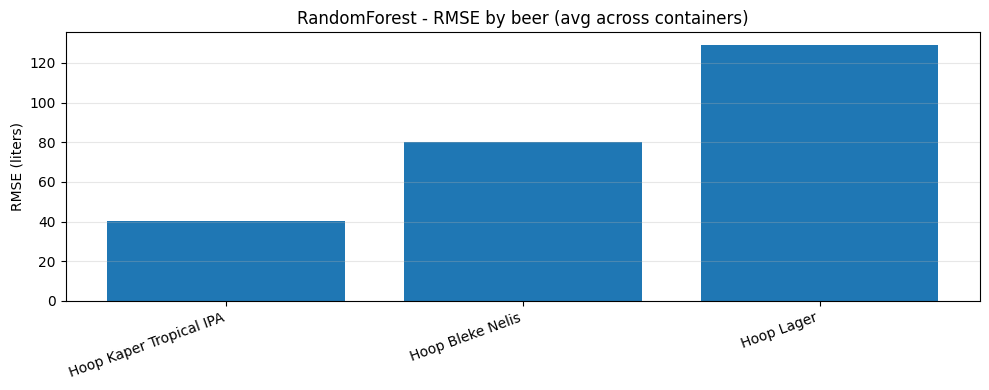

In [17]:
# 5) Random Forest
m, p = run_model(
    "RandomForest",
    model_factory=lambda y_train: RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
)
MODEL_RESULTS["RandomForest"] = {"metrics": m, "preds": p}

Model: HistGradientBoosting
           MAE       RMSE      SMAPE
avg  45.590117  71.770939  135.74108


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,36.076990,48.595348,129.027025
0,Hoop Bleke Nelis,33.017845,59.041546,116.537282
2,Hoop Lager,68.440303,105.064373,164.781370


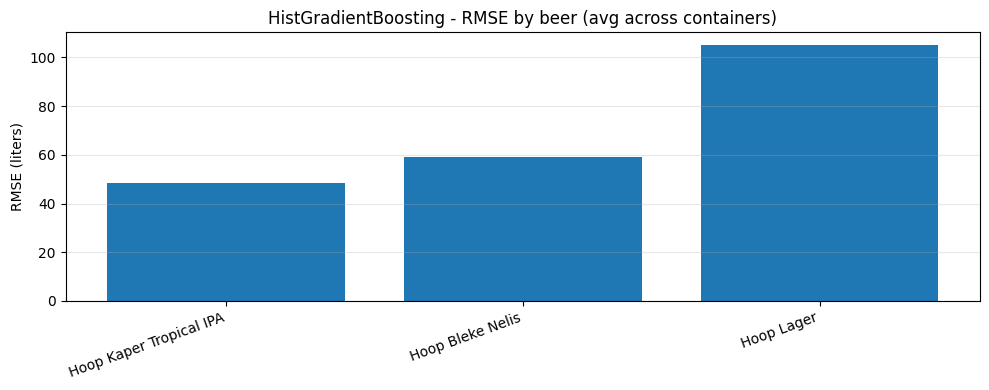

In [18]:
# 6) HistGradientBoosting
m, p = run_model(
    "HistGradientBoosting",
    model_factory=lambda y_train: HistGradientBoostingRegressor(
        loss="poisson" if float(y_train.sum()) > 0 else "squared_error",
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    ),
)
MODEL_RESULTS["HistGradientBoosting"] = {"metrics": m, "preds": p}

/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

Model: ARIMA(2,1,2)
           MAE       RMSE      SMAPE
avg  57.165282  76.635086  125.41375


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,31.124241,38.968515,86.433881
0,Hoop Bleke Nelis,43.848624,62.030207,120.145532
2,Hoop Lager,93.341887,123.141113,161.233926


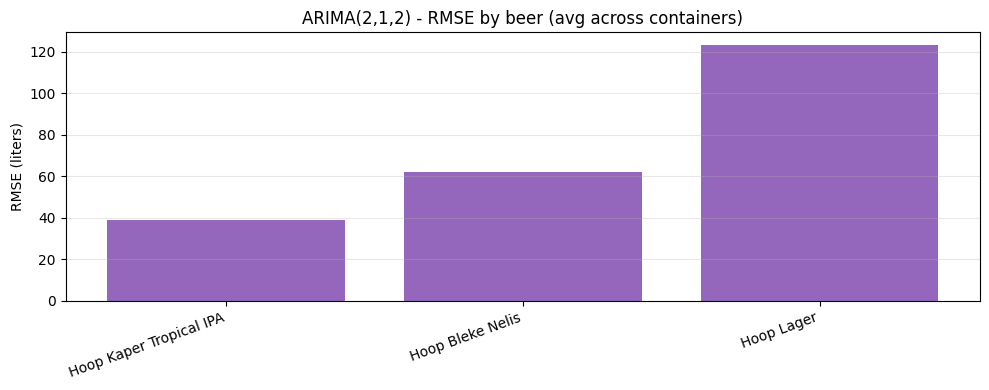

In [19]:
# 7) ARIMA (time-series)
m, p = run_time_series_model(
    "ARIMA(2,1,2)",
    ts_predict_fn=lambda train, test: recursive_predict_arima(train, test, order=(2, 1, 2)),
)
MODEL_RESULTS["ARIMA(2,1,2)"] = {"metrics": m, "preds": p}

Model: HoltWinters_Additive
           MAE       RMSE       SMAPE
avg  59.943658  90.775147  148.058576


,beer,MAE,RMSE,SMAPE
1,Hoop Kaper Tropical IPA,39.287345,53.712617,136.466579
0,Hoop Bleke Nelis,50.471643,84.410228,141.673136
2,Hoop Lager,87.275911,126.528194,164.734375


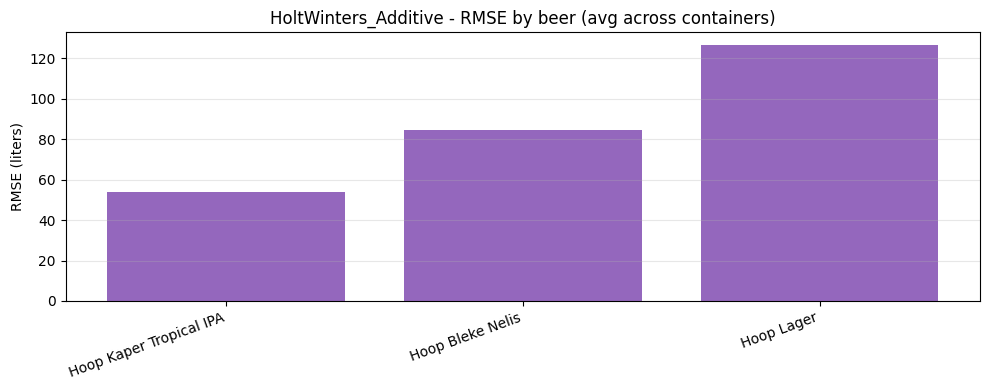

In [20]:
# 8) Holt-Winters / Exponential Smoothing (time-series)
m, p = run_time_series_model(
    "HoltWinters_Additive",
    ts_predict_fn=lambda train, test: recursive_predict_holt_winters(train, test, seasonal_periods=52),
)
MODEL_RESULTS["HoltWinters_Additive"] = {"metrics": m, "preds": p}

Overall leaderboard (lower is better):


,model,MAE,RMSE,SMAPE
0,HistGradientBoosting,45.590117,71.770939,135.741080
1,"ARIMA(2,1,2)",57.165282,76.635086,125.413750
2,Ridge,54.333342,77.351914,108.047920
3,LinearRegression,54.563708,77.700067,108.443659
4,Naive_Last_Week,61.129744,81.928515,85.902102
5,RandomForest,59.184090,86.414110,111.272154
6,HoltWinters_Additive,59.943658,90.775147,148.058576
7,Naive_Seasonal_52,60.210545,111.442947,86.586838


Best model per beer (by RMSE):


,beer,model,MAE,RMSE,SMAPE
0,Hoop Bleke Nelis,HistGradientBoosting,33.017845,59.041546,116.537282
1,Hoop Kaper Tropical IPA,"ARIMA(2,1,2)",31.124241,38.968515,86.433881
2,Hoop Lager,HistGradientBoosting,68.440303,105.064373,164.781370


model,"ARIMA(2,1,2)",HistGradientBoosting,HoltWinters_Additive,LinearRegression,Naive_Last_Week,Naive_Seasonal_52,RandomForest,Ridge
beer,,,,,,,,
Hoop Bleke Nelis,62.03,59.04,84.41,64.60,75.89,130.03,79.92,64.11
Hoop Kaper Tropical IPA,38.97,48.60,53.71,44.81,48.95,55.35,40.48,44.18
Hoop Lager,123.14,105.06,126.53,118.75,114.21,130.27,128.99,118.78


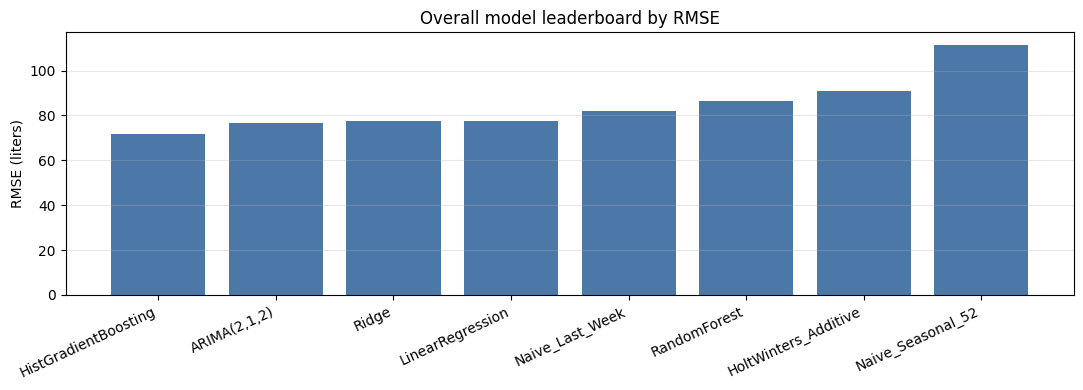

Saved:
- data/processed/model_leaderboard_overall.csv
- data/processed/model_leaderboard_best_per_beer.csv
- data/processed/model_leaderboard_all_series_metrics.csv


In [21]:
# 9) Final leaderboard summary across all model cells
all_metrics = []
for model_name, payload in MODEL_RESULTS.items():
    mdf = payload.get("metrics")
    if mdf is not None and not mdf.empty:
        all_metrics.append(mdf.copy())

if not all_metrics:
    print("No model results found yet. Run the model cells first.")
else:
    combined = pd.concat(all_metrics, ignore_index=True)

    overall = (
        combined.groupby("model", as_index=False)[["MAE", "RMSE", "SMAPE"]]
        .mean()
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    print("Overall leaderboard (lower is better):")
    display(overall)

    per_beer = (
        combined.groupby(["beer", "model"], as_index=False)[["MAE", "RMSE", "SMAPE"]]
        .mean()
    )

    best_per_beer = (
        per_beer.sort_values(["beer", "RMSE", "MAE"])  # RMSE primary, MAE tiebreak
        .groupby("beer", as_index=False)
        .first()
        .sort_values("beer")
        .reset_index(drop=True)
    )

    print("Best model per beer (by RMSE):")
    display(best_per_beer)

    # Heatmap-style pivot for quick scan
    rmse_pivot = (
        per_beer.pivot(index="beer", columns="model", values="RMSE")
        .sort_index()
    )
    display(rmse_pivot.style.format("{:.2f}").background_gradient(cmap="RdYlGn_r", axis=None))

    # Overall RMSE bar chart
    plt.figure(figsize=(11, 4))
    plt.bar(overall["model"], overall["RMSE"], color="#4c78a8")
    plt.title("Overall model leaderboard by RMSE")
    plt.ylabel("RMSE (liters)")
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save outputs
    overall.to_csv("data/processed/model_leaderboard_overall.csv", index=False)
    best_per_beer.to_csv("data/processed/model_leaderboard_best_per_beer.csv", index=False)
    combined.to_csv("data/processed/model_leaderboard_all_series_metrics.csv", index=False)

    print("Saved:")
    print("- data/processed/model_leaderboard_overall.csv")
    print("- data/processed/model_leaderboard_best_per_beer.csv")
    print("- data/processed/model_leaderboard_all_series_metrics.csv")

In [ ]:
# 10) Extra model comparison views: per-model test predictions vs actual
all_metrics = []
all_preds = []
for model_name, payload in MODEL_RESULTS.items():
    mdf = payload.get("metrics")
    pdf = payload.get("preds")
    if mdf is not None and not mdf.empty:
        all_metrics.append(mdf.copy())
    if pdf is not None and not pdf.empty:
        all_preds.append(pdf.copy())

if not all_preds:
    print("No prediction outputs found. Run model cells first.")
else:
    metrics_all = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
    preds_all = pd.concat(all_preds, ignore_index=True)

    # Additional comparison metrics
    if not metrics_all.empty:
        extra = preds_all.copy()
        extra["error"] = extra["pred_liters"] - extra["actual_liters"]
        extra["abs_error"] = extra["error"].abs()

        extra_summary = (
            extra.groupby("model", as_index=False)
            .agg(
                mean_error_liters=("error", "mean"),       # bias: + overforecast / - underforecast
                wape=("abs_error", "sum"),
                total_actual=("actual_liters", "sum"),
            )
        )
        extra_summary["WAPE_pct"] = 100 * extra_summary["wape"] / extra_summary["total_actual"].replace(0, np.nan)
        extra_summary = extra_summary.drop(columns=["wape", "total_actual"]).sort_values("WAPE_pct")

        print("Extra diagnostics (lower WAPE and near-zero mean_error are better):")
        display(extra_summary)

    model_list = sorted(preds_all["model"].unique())
    n_models = len(model_list)

    # A) One line chart per model: aggregated weekly actual vs predicted on the test horizon
    fig, axes = plt.subplots(n_models, 1, figsize=(14, 3.2 * n_models), sharex=False)
    if n_models == 1:
        axes = [axes]

    for ax, model_name in zip(axes, model_list):
        g = preds_all[preds_all["model"] == model_name].copy()
        weekly = g.groupby("week", as_index=False).agg(
            actual_liters=("actual_liters", "sum"),
            pred_liters=("pred_liters", "sum"),
        )
        ax.plot(weekly["week"], weekly["actual_liters"], color="black", linewidth=2.2, label="Actual")
        ax.plot(weekly["week"], weekly["pred_liters"], color="#1f77b4", linestyle="--", linewidth=2.0, label="Predicted")
        ax.set_title(f"{model_name} — test period (aggregated across beer x container)")
        ax.set_ylabel("Liters")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

    # B) Scatter per model: actual vs predicted (all test points)
    n_cols = 3
    n_rows = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, model_name in enumerate(model_list):
        ax = axes[i]
        g = preds_all[preds_all["model"] == model_name].copy()
        ax.scatter(g["actual_liters"], g["pred_liters"], alpha=0.35, s=16, color="#2ca02c")

        vmin = min(g["actual_liters"].min(), g["pred_liters"].min())
        vmax = max(g["actual_liters"].max(), g["pred_liters"].max())
        ax.plot([vmin, vmax], [vmin, vmax], color="red", linewidth=1.5)

        ax.set_title(model_name)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.grid(alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    preds_all.to_csv("data/processed/model_test_predictions_long.csv", index=False)
    print("Saved: data/processed/model_test_predictions_long.csv")